## Atlantis PAH PC injection from surface spill of dilbit at Turn Point
Dilbit Tanker fails to make the turn in outbound shipping lane at Turn Point and hits Arachne Reef, spilling 2000 m<sup>-3</sup> of Dilbit.

In [1]:
import os
import xarray as xr
import numpy as np
import itertools
import pandas as pd
from pathlib import Path
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ssam_groups as groups
from mpl_toolkits.axes_grid1 import make_axes_locatable

### Define scenario and control files

In [2]:
hex_colour = '#6DB48E'
hatches = ['oo', '///', 'xx', '++']

In [3]:
# Oil injection file 
oil_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/ForcingFiles/')
oil_paths = sorted([p for p in oil_root.glob('SSAM_Scenario_5b*-01-*_10000_WSFmean.nc')])
oil_files = [xr.open_dataset(oil_scen,decode_cf=True) for oil_scen in oil_paths]

In [4]:
# Read in salish sea atlantis output files.
scenario_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1')

control_file = "/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/Control/highres-control-3y-2019-2022/outputSalishSea.nc"
control = xr.open_dataset(str(control_file), decode_cf=True)
time = np.ma.filled(control.variables['t'])


In [5]:
scenario_paths = sorted([p for p in scenario_root.glob('highres-2019-2022_5b*/outputSalishSea.nc')])
for path in scenario_paths:
    print(path.parent.stem, groups.conditions[str(path.parent.stem).split(sep = '_')[3]])

highres-2019-2022_5b_1_2019-01-20 low Fraser spring tide
highres-2019-2022_5b_2_2019-01-14 low Fraser neap tide
highres-2019-2022_5b_3_2020-01-24 high Fraser spring tide
highres-2019-2022_5b_4_2020-01-16 high Fraser neap tide


In [6]:
scenario_datasets = [xr.open_dataset(scen,decode_cf=True) for scen in scenario_paths]

In [7]:
# time after burn-in
start = 0
end = time.size-1

In [8]:
# Reading in Atlantis map
shapefile_name = "/ocean/rlovindeer/Atlantis/ssam_oceanparcels/SalishSea/SalishSea_July172019_2/SalishSea_July172019.shp"
data_df_original = gpd.read_file(shapefile_name)
data_df_original = data_df_original.sort_values(by=['BOX_ID'])
data_df = data_df_original.set_index('BOX_ID')
box_depth = data_df['BOTZ']
land_boxes = box_depth==0
land_boxes = data_df.index[land_boxes]
land_df = data_df.loc[land_boxes]
jdf_df = data_df.loc[data_df.Region=='Juan de Fuca']
hs_df = data_df.loc[data_df.Region=='Howe Sound']
strait_df = data_df.loc[data_df.Region=='Strait of Georgia']
ps_df = data_df.loc[data_df.Region=='Puget Sound']

### Mapping spill extent

TP-FlTn BOX_ID
60    322474724
Name: AREA, dtype: int64
TP-FlTs BOX_ID
8     485601055
9     288060859
60    322474724
Name: AREA, dtype: int64
TP-FhTn BOX_ID
34    116214640
60    322474724
Name: AREA, dtype: int64
TP-FhTs BOX_ID
60    322474724
Name: AREA, dtype: int64


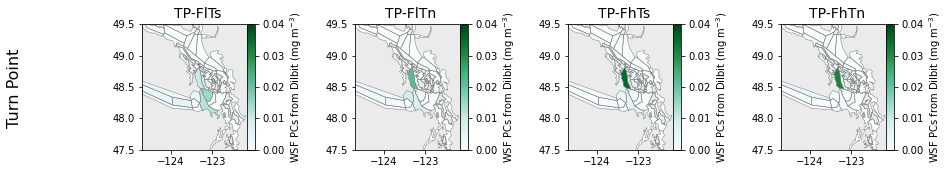

In [9]:
fig = plt.figure(figsize=(14, 6), facecolor='white') #figsize=(9, 12)
gs = plt.GridSpec(1, len(oil_files), wspace=0.5, hspace=0.2, height_ratios=[1],)

for file, oil_path in zip(oil_files, oil_paths):
    date = str(oil_path).split(sep = '_')[3]
    label = 'TP-'+ groups.conditions_with_letters[str(groups.simulations[groups.conditions[date]])]
    position = int(str(groups.simulations[groups.conditions[date]]))-1
    oil_tb = file.variables['TPAH']
    oil_b = oil_tb.mean(axis=0)

    # Add scenario data to Atlantis spatial data
    data_df['TPAH'] = oil_b
    data_df.loc[land_boxes, 'TPAH'] = 0
    oil_df = data_df.loc[data_df['TPAH'] > 0.01] 
    print(label,oil_df.AREA)

    ax = fig.add_subplot(gs[0, position], facecolor = '#EBEBEB')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=-0.5)
    ax = data_df.plot(column = 'TPAH', ax=ax, cax=cax,cmap=cm.BuGn, legend_kwds={'label': 'WSF PCs from Dilbit (mg m$^{-3}$)'}, vmax=0.04,
    #ax = data_df.plot(column = 'BOTZ', ax=ax, cax=cax,cmap=cm.Blues, legend_kwds={'label': 'depth (m)'},
    legend=True, 
    )
    ax.set_title(label, fontsize = 14)
    ax.set_xlim(-124.7)
    ax.set_ylim(47.5, 49.5)
    data_df.boundary.plot(ax=ax, color='grey', linewidths=0.5)
    land_df.plot(ax=ax, color='#EBEBEB')
    #oil_df.plot(ax=ax, color='red',linewidths=0.5)
fig.supylabel('Turn Point', fontsize = 16); #color=hex_colour
#fig.savefig("Figures/spill-map-TP.png", dpi=300, bbox_inches='tight')

In [10]:
affected_boxes = [8, 9, 34, 60]

In [11]:
for box in affected_boxes:
    print('Box '+str(box)+' Depth(m) '+str(data_df.BOTZ[box]))

Box 8 Depth(m) 100
Box 9 Depth(m) 100
Box 34 Depth(m) 100
Box 60 Depth(m) 50


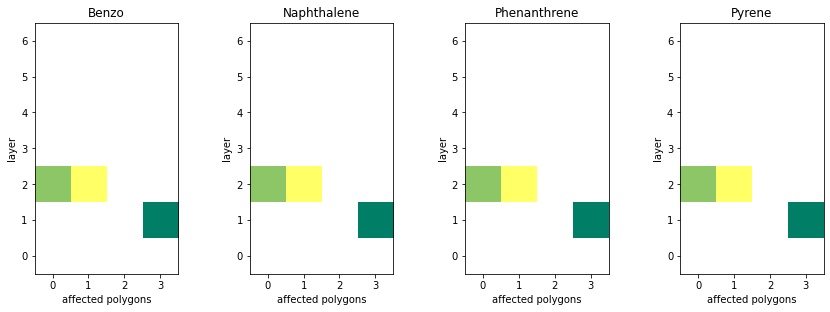

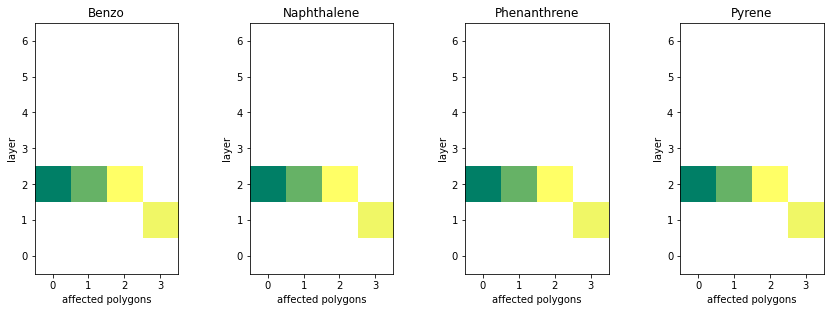

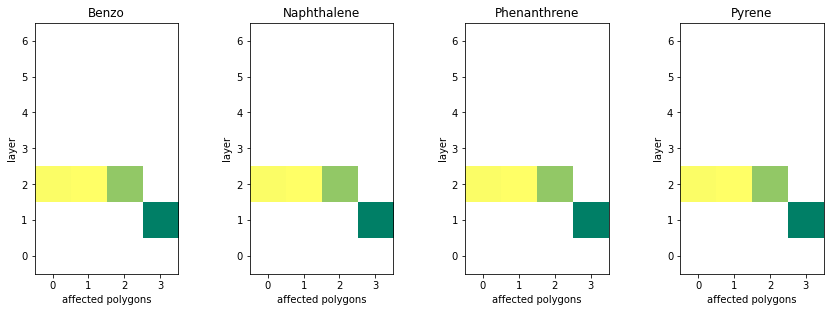

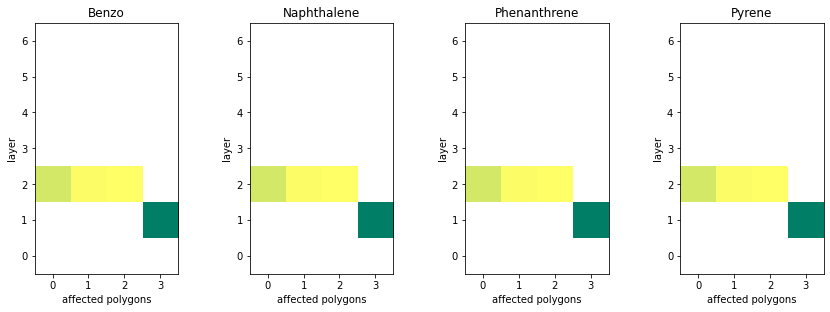

In [12]:
for file in oil_files:
    fig = plt.figure(figsize=(18, 6), facecolor='white') #figsize=(9, 12)
    gs = plt.GridSpec(1, 5, wspace=0.5, hspace=0.2, height_ratios=[1],)
    for pah in groups.pahs:
        ax = fig.add_subplot(gs[0, list(groups.pahs).index(pah)])
        contam_bl = file.variables[str(pah)][8][affected_boxes][:]
        contam = contam_bl.transpose()
        ax.imshow(contam, cmap=cm.summer_r) #copper_r
        ax.invert_yaxis() 
        ax.set_title(str(pah), fontsize = 12)
        ax.set_ylabel('layer')
        ax.set_xlabel('affected polygons')

#### Concentration of PAH in seawater

Half lives

| PAH Concentration	|	Naphthalene |	Phenanthrene | Pyrene |	Benzo(a)pyrene |
|-------------------|---------------|-----------------|--------|----------|
| Half life (secs)	|	259200 |	3628800	| 20476800	| 19353600 |
| Half life (days)	|	3	| 42 |	237 |	224 |

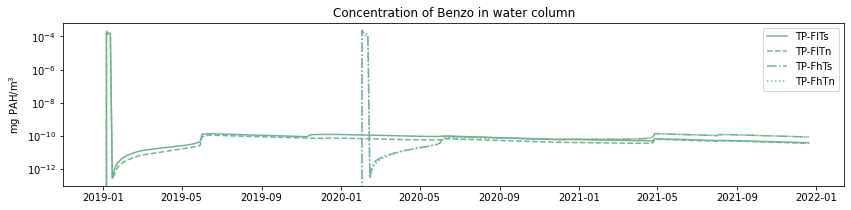

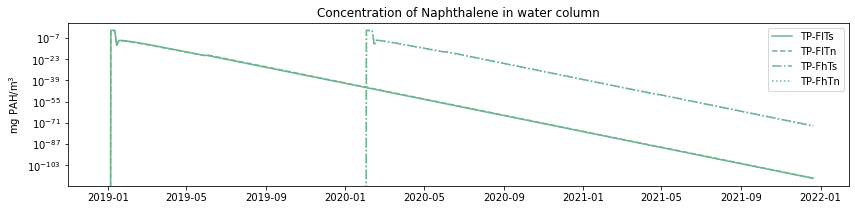

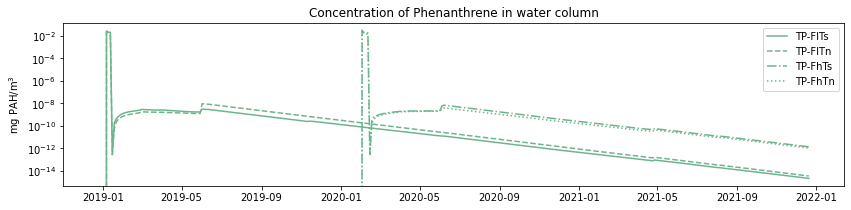

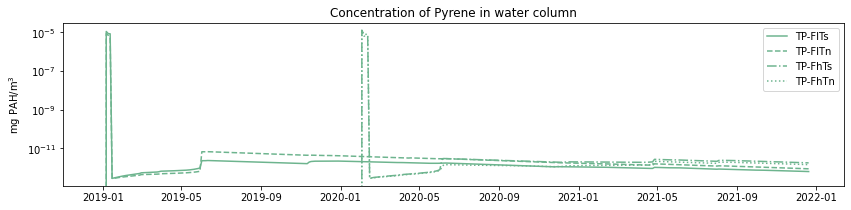

In [13]:
for pah in groups.pahs:
  fig, ax = plt.subplots(figsize = (14,3))
  names = []
  line_styles = itertools.cycle(('-', '--', '-.', ':',(5, (10, 3)),
    (0, (3, 1, 1, 1)),(0, (1, 1)),(0, (3, 10, 1, 10, 1, 10))))
  for scenario, path, i in zip(scenario_datasets,scenario_paths,range(0,len(scenario_datasets))):
      nm = path.parent.stem.split(sep = '_')
      names.append('TP-'+groups.conditions_with_letters[str(nm[2])])
      contam_tbl = scenario.variables[str(pah)][start:end,:,0:6]
      contam_tb = contam_tbl.sum(axis=2)
      contam_t = contam_tb.sum(axis=1)
      ax.semilogy(scenario.t[start:end], contam_t, color=hex_colour, linestyle=next(line_styles))
  ax.set_title('Concentration of '+ pah +' in water column', fontsize = 12)
  ax.set_ylabel('mg PAH/m$^3$')
  ax.legend(names, loc='best')

## Regional Results

In [14]:
def plot_groups_benthic_N(bio_group, scenario_datasets, scenario_paths, control=control, boxes=groups.salish_sea, y_min=None, y_max=None):

    fig = plt.figure(figsize=(18, 18), facecolor='white')
    gs = plt.GridSpec(3, 3, wspace=0.2, hspace=0.2, width_ratios=[1, 1, 1], height_ratios=[1, 1, 1], )
    line_styles = itertools.cycle(('-', '--', '-.', ':',(5, (10, 3)),
    (0, (3, 1, 1, 1)),(0, (1, 1)),(0, (3, 10, 1, 10, 1, 10))))

    for species in bio_group:
        names = ['control']
        bio_index = (list(bio_group).index(species))
        if bio_index < 3:
            position = 0, bio_index
        elif bio_index > 5: 
            position = 2, bio_index-6
        else :
            position = 1, bio_index-3
        ax = fig.add_subplot(gs[position])

        pelagic_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:,boxes], np.nan)
        pelagic_control = pelagic_control.sum(axis=1)+groups.base_biomass[bio_group[species]]
        control_ratio = (pelagic_control / pelagic_control-1)*100
        ax.plot(control.t, control_ratio, 'k', linewidth = 2)
    
        for scenario, path in zip(scenario_datasets, scenario_paths):
            nm = str(path.parent.stem).split(sep='_')
            scenario_name = 'TP-'+groups.conditions_with_letters[nm[2]]
            names.append(scenario_name)

            pelagic_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:,boxes], np.nan) # tonnes
            pelagic_oiled = pelagic_oiled.sum(axis=1)+groups.base_biomass[bio_group[species]]
            ratio = (pelagic_oiled / pelagic_control-1)*100
            ax.plot(scenario.t, ratio, linewidth = 2, color=hex_colour, linestyle=next(line_styles))
        ax.fill_between(scenario.t, -groups.sensitivity[bio_group[species]], groups.sensitivity[bio_group[species]],
            color='grey', alpha=0.3, label='Model threshold')
       
        ax.set_ylabel('Percent (%) change', fontsize=12)
        ax.set_title(species)
        ax.set_ylim([y_min, y_max])
        ylabels = ax.get_yticklabels()
        xlabels = ax.get_xticklabels()
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.legend(names, fontsize=12); #bbox_to_anchor=(1.05, 1)

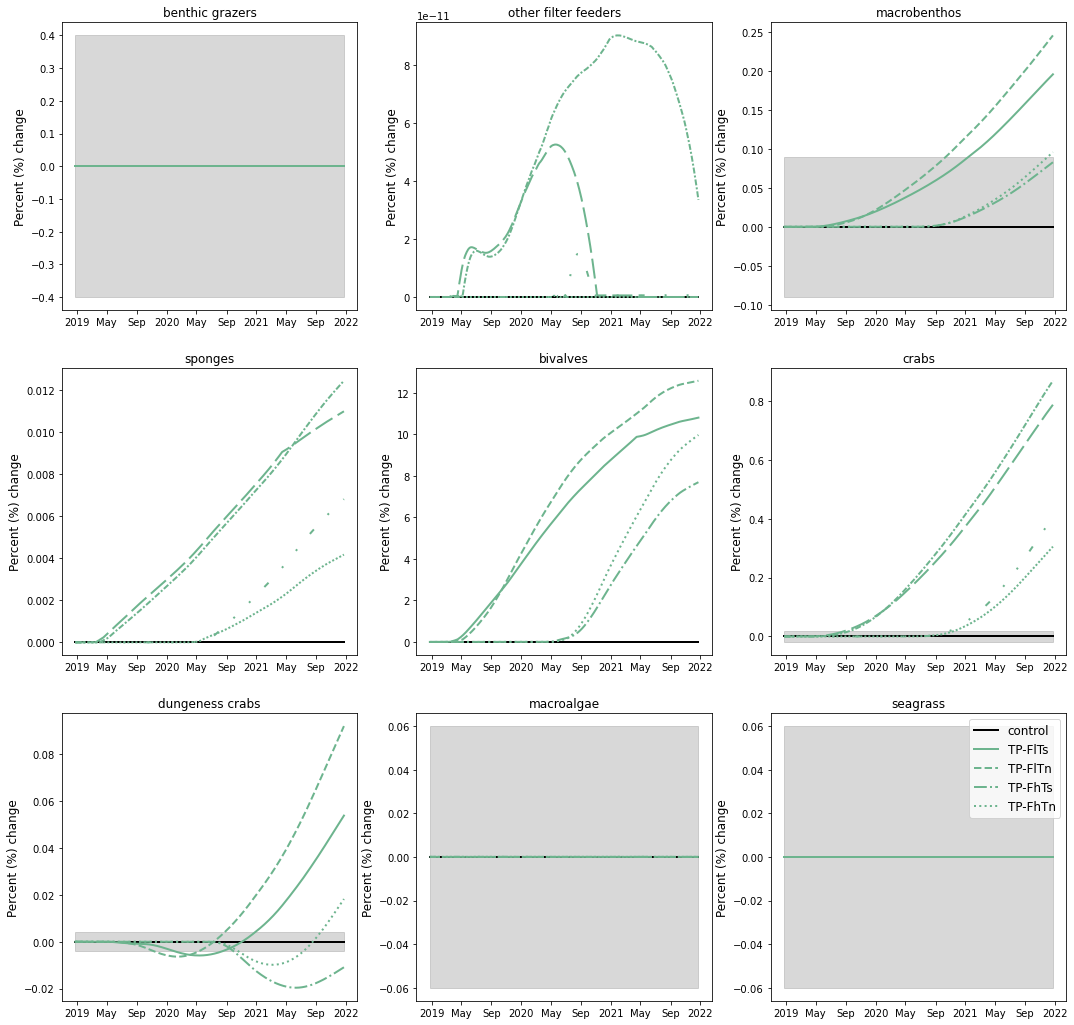

In [15]:
plot_groups_benthic_N(groups.benthos, scenario_datasets, scenario_paths, control=control, boxes=affected_boxes)

In [16]:
def plot_benthic_biomass(bio_group, scenario_datasets, scenario_paths, control=control, boxes=groups.salish_sea, y_min=None, y_max=None):

    fig = plt.figure(figsize=(18, 18), facecolor='white')
    gs = plt.GridSpec(3, 3, wspace=0.2, hspace=0.2, width_ratios=[1, 1, 1], height_ratios=[1, 1, 1], )
    line_styles = itertools.cycle(('-', '--', '-.', ':',(5, (10, 3)),
    (0, (3, 1, 1, 1)),(0, (1, 1)),(0, (3, 10, 1, 10, 1, 10))))

    for species in bio_group:
        names = ['control']
        bio_index = (list(bio_group).index(species))
        if bio_index < 3:
            position = 0, bio_index
        elif bio_index > 5: 
            position = 2, bio_index-6
        else :
            position = 1, bio_index-3
        ax = fig.add_subplot(gs[position])

        pelagic_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:,boxes], np.nan)
        pelagic_control = pelagic_control.sum(axis=1)+groups.base_biomass[bio_group[species]]
        ax.plot(control.t, pelagic_control, 'k')
    
        for scenario, path in zip(scenario_datasets, scenario_paths):
            nm = str(path.parent.stem).split(sep='_')
            scenario_name = 'TP-'+groups.conditions_with_letters[nm[2]]
            names.append(scenario_name)

            pelagic_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:,boxes], np.nan) # tonnes
            pelagic_oiled = pelagic_oiled.sum(axis=1)+groups.base_biomass[bio_group[species]]
            ax.plot(scenario.t, pelagic_oiled, linewidth = 2, color=hex_colour, linestyle=next(line_styles))
        
        ax.set_ylabel('Biomass', fontsize=12)
        ax.set_title(species)
        ax.set_ylim([y_min, y_max])
        ylabels = ax.get_yticklabels()
        xlabels = ax.get_xticklabels()
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.legend(names, fontsize=12); #bbox_to_anchor=(1.05, 1)

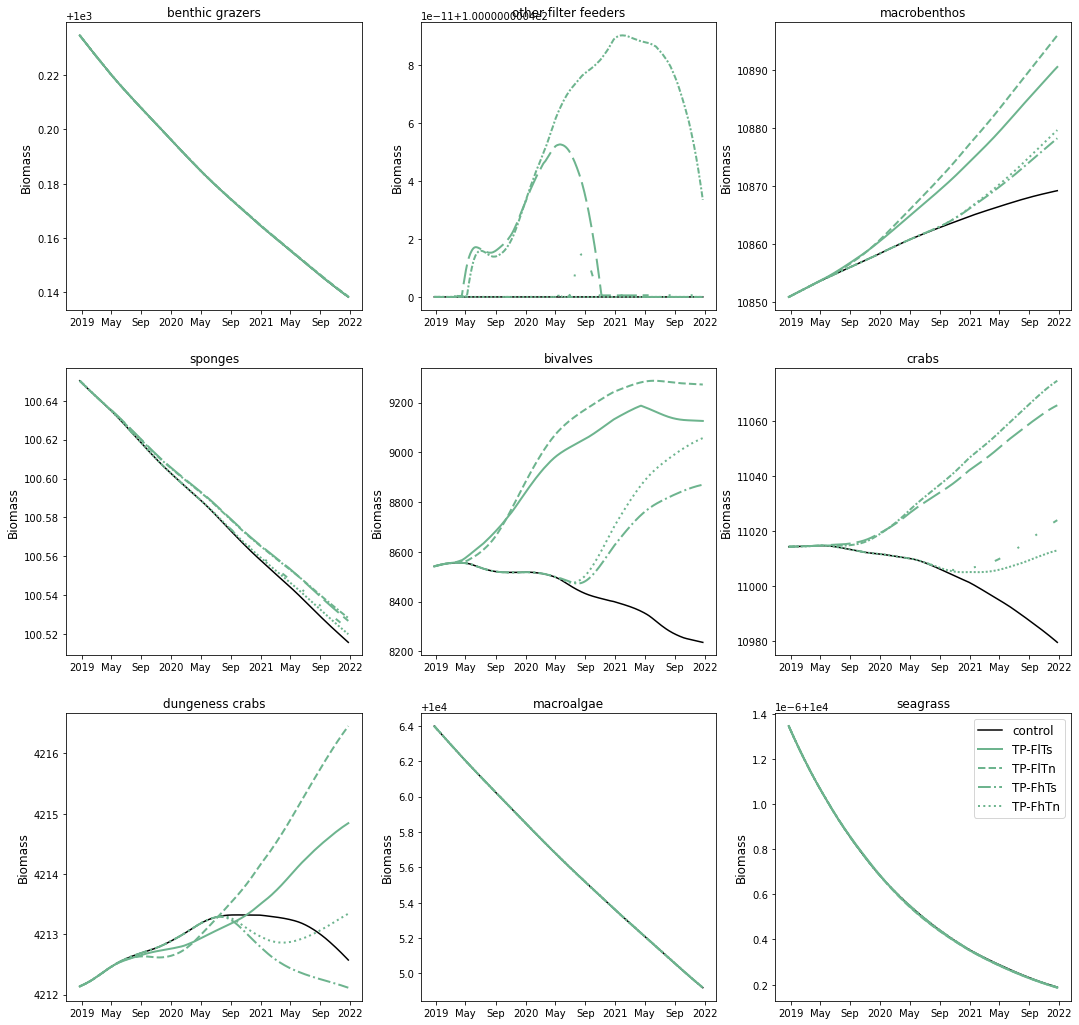

In [17]:
plot_benthic_biomass(groups.benthos, scenario_datasets, scenario_paths, boxes=affected_boxes)

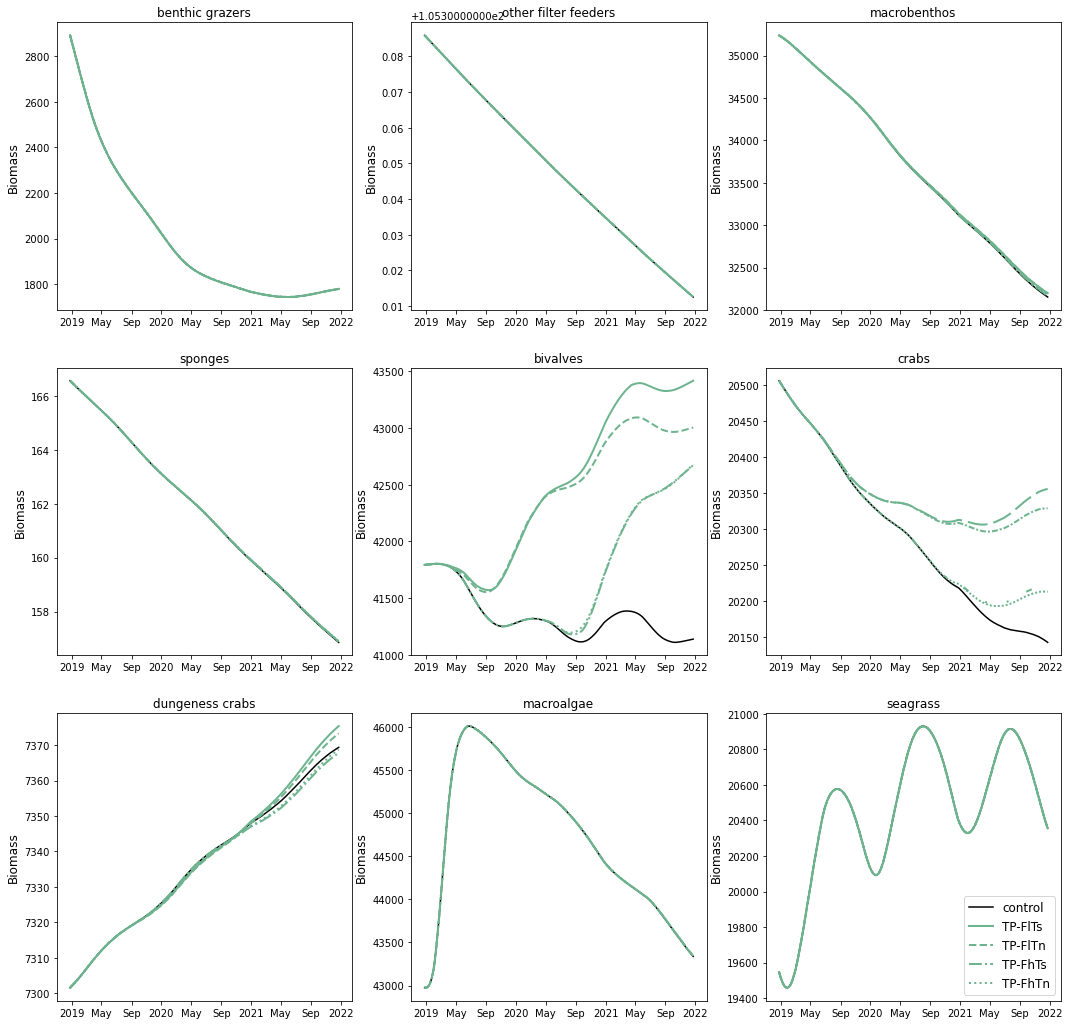

In [18]:
plot_benthic_biomass(groups.benthos, scenario_datasets, scenario_paths) #entire Salish Sea